# Dominant eigenvector on the circle

This first problem follows the classical sphere example used to introduce
[Manopt](https://www.manopt.org/firstexample.html) and
[Pymanopt](https://pymanopt.org/docs/stable/quickstart.html). We use
$S^1\subset\mathbb{R}^2$ so that the optimizer and objective can be seen
directly.

For a symmetric matrix $A$, a dominant eigenvector maximizes the Rayleigh
quotient. On the unit circle the denominator is one, so the problem is

$$
\min_{x\in S^1} f(x),
\qquad f(x)=-x^\top A x.
$$

The sign is not identifiable: $x$ and $-x$ represent equally valid
eigenvectors.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

from geojax.geometry import Sphere
from geojax.optimization import ConjugateGradient, Minimize

plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 240,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

A = jnp.array([[3.0, 1.0], [1.0, 1.0]])
M = Sphere(size=2)
x0 = M.project(jnp.array([-0.15, 1.0]))

def cost(x):
    return -x @ A @ x

GeoJAX obtains the ambient derivative of `cost` with JAX, projects it to the
tangent line, and follows geodesics on the circle.

In [2]:
problem = Minimize(
    M=M,
    cost=cost,
    x0=x0,
    solver=ConjugateGradient(maxiter=80, tolgradnorm=1e-10, verbosity=0),
)
x_hat, final_cost, history = problem.solve()

eigenvalues, eigenvectors = jnp.linalg.eigh(A)
x_exact = eigenvectors[:, -1]
if jnp.dot(x_hat, x_exact) < 0:
    x_hat = -x_hat

angle_error = jnp.arccos(jnp.clip(jnp.dot(x_hat, x_exact), -1.0, 1.0))
print(f"largest eigenvalue : {float(eigenvalues[-1]):.10f}")
print(f"estimated vector   : {x_hat}")
print(f"angular error      : {float(angle_error):.3e} radians")
print(f"iterations         : {history[-1].iter}")

largest eigenvalue : 3.4142135624
estimated vector   : [-0.92387953 -0.38268343]
angular error      : 0.000e+00 radians
iterations         : 15


## Visual report

The first panel places the initial, exact, and estimated vectors in Cartesian
coordinates. The objective is periodic in the angle and has two equivalent
minima. The final panel shows convergence of the Riemannian gradient norm.

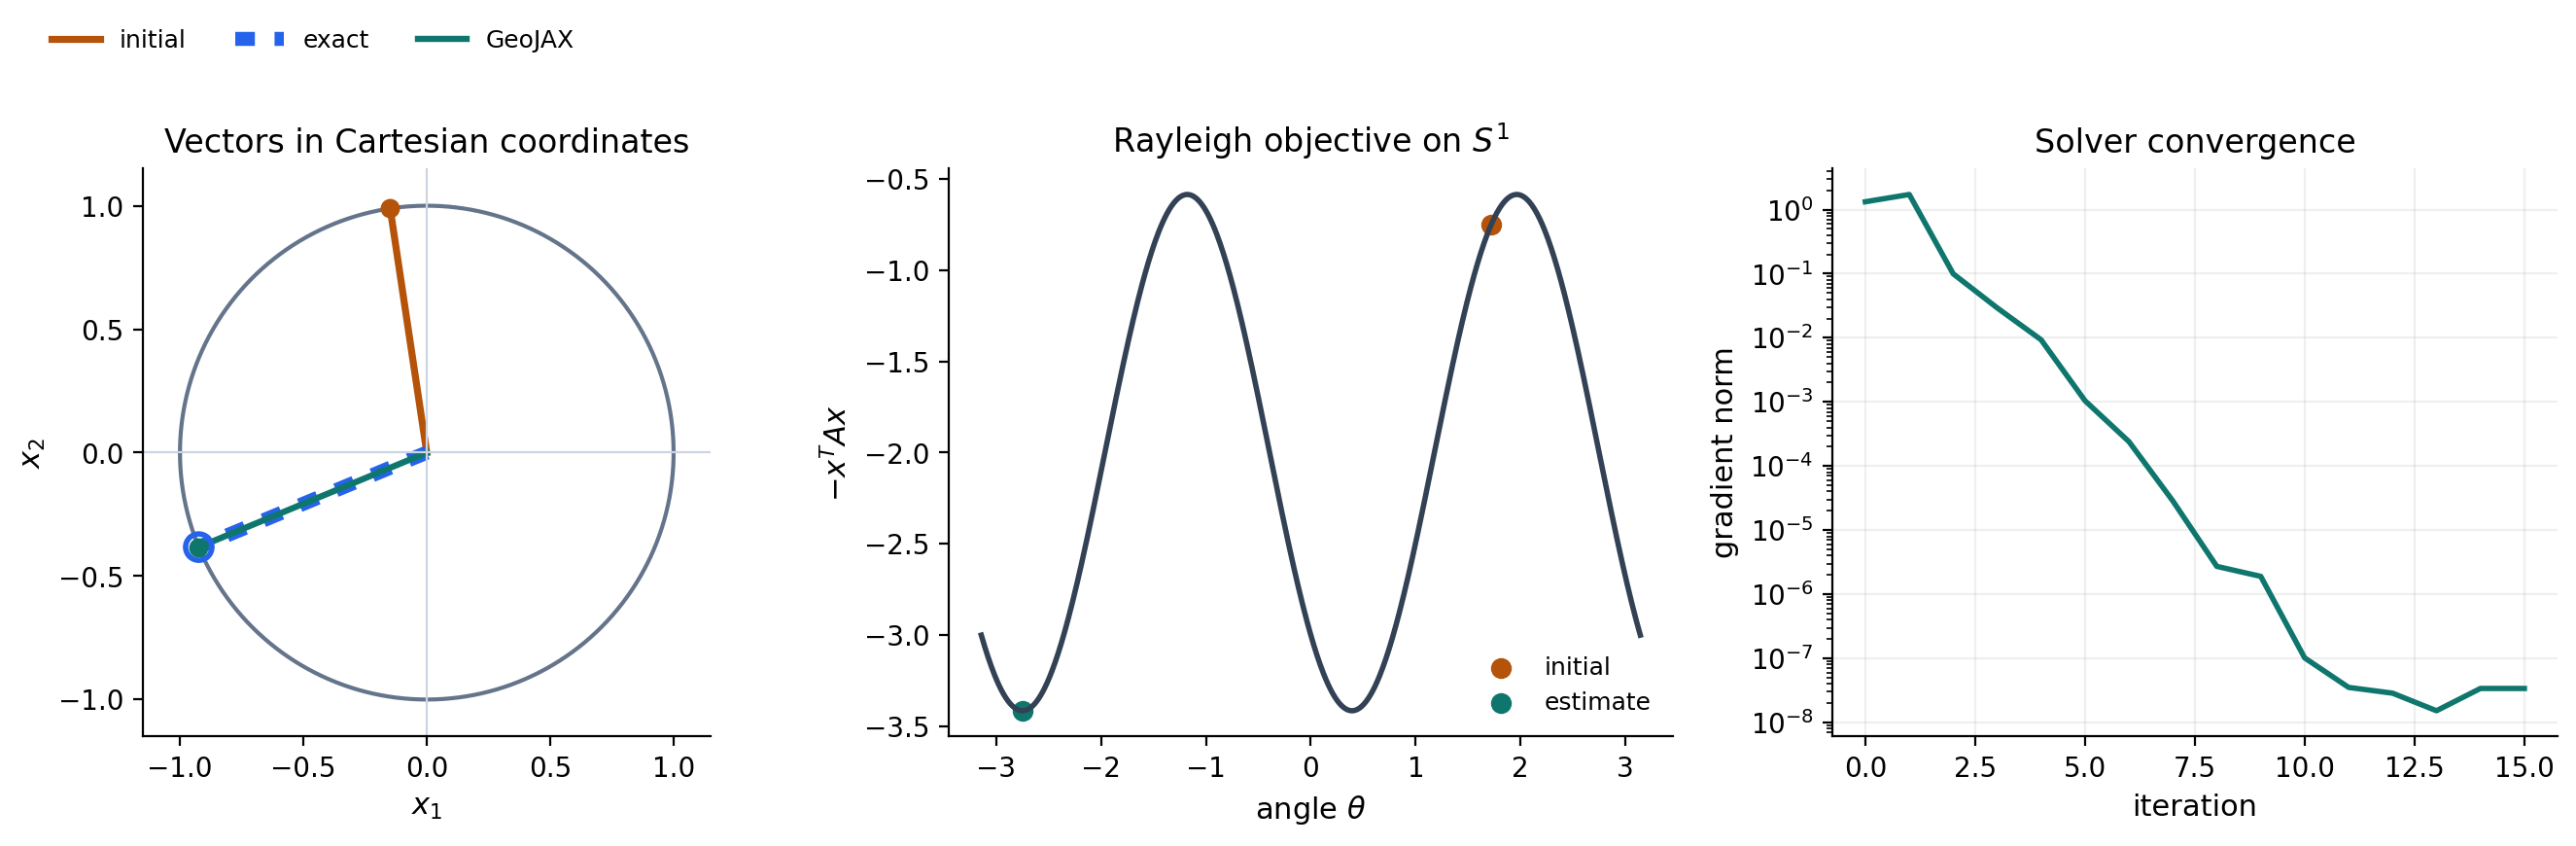

In [3]:
theta = jnp.linspace(-jnp.pi, jnp.pi, 600)
circle = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=1)
landscape = jax.vmap(cost)(circle)
theta0 = jnp.arctan2(x0[1], x0[0])
theta_hat = jnp.arctan2(x_hat[1], x_hat[0])
gradnorm = jnp.array([max(row.gradnorm, 1e-16) for row in history])

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.4))

ax = axes[0]
ax.plot(circle[:, 0], circle[:, 1], color="#64748b", linewidth=1.5)
for vector, color, label, style, linewidth in [
    (x0, "#b45309", "initial", "-", 2.6),
    (x_exact, "#2563eb", "exact", (0, (1.4, 1.4)), 5.2),
    (x_hat, "#0f766e", "GeoJAX", "-", 2.3),
]:
    ax.plot([0, vector[0]], [0, vector[1]], color=color, linestyle=style,
            linewidth=linewidth, label=label)
    if label == "exact":
        ax.scatter(
            vector[0], vector[1], facecolors="none", edgecolors=color,
            linewidth=2.0, s=95, zorder=3,
        )
    else:
        ax.scatter(vector[0], vector[1], color=color, s=38, zorder=4)
ax.axhline(0, color="#cbd5e1", linewidth=0.8)
ax.axvline(0, color="#cbd5e1", linewidth=0.8)
ax.set(xlim=(-1.15, 1.15), ylim=(-1.15, 1.15), aspect="equal",
       title="Vectors in Cartesian coordinates", xlabel="$x_1$", ylabel="$x_2$")
vector_legend = ax.get_legend_handles_labels()

ax = axes[1]
ax.plot(theta, landscape, color="#334155", linewidth=2)
ax.scatter([theta0], [cost(x0)], color="#b45309", s=45, label="initial")
ax.scatter([theta_hat], [cost(x_hat)], color="#0f766e", s=45, label="estimate")
ax.set(title="Rayleigh objective on $S^1$", xlabel="angle $\\theta$", ylabel="$-x^T A x$")
ax.legend(frameon=False)

ax = axes[2]
ax.semilogy(jnp.arange(len(history)), gradnorm, color="#0f766e", linewidth=2)
ax.set(title="Solver convergence", xlabel="iteration", ylabel="gradient norm")
ax.grid(alpha=0.2)

fig.legend(
    *vector_legend,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.045, 0.995),
    ncol=3,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
plt.show()

The estimated vector agrees with the direct eigendecomposition up to numerical
precision. More importantly, every iterate remains on the unit circle; no
penalty or post-hoc normalization is needed in the optimization model.